# CS 503 Foundation Models: Part 2 - nanoMaskGIT

#### Goals:

The goal of this second part is to familiarize yourself with the following topics:
- Bi-directional attention
- Encoder-only Transformer (e.g. BERT, MaskGIT, ...) models
- Basic masking schemes
- Masked modelling on text and images
- Masked inference

This notebook should give you a solid foundation of working with masked image models.
If you want to know more about these topics, please see some of the reading material in the lectures and at the bottom of this notebook, and feel free to ask the TAs.


#### Instructions:

- Your task is to fill in the missing code in the acompagning codebase (highlighted by `???`), run the training loops and evaluate the trained models with this notebook.
- Submit the notebook with all cells executed, as well as `nanofm/models/maskgit.py`.
- The notebooks are individual homework.

# 1. Setup

Please follow the instructions in the [README.md](../README.md) file to set up the environment.

### 1.1 Imports

In [1]:
# Switch path to root of project
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"
current_folder = globals()['_dh'][0]
os.chdir(os.path.dirname(os.path.abspath(current_folder)))

%load_ext autoreload
%autoreload 2

In [2]:
import re
import torch
from einops import rearrange
from transformers import AutoTokenizer
from tokenizers.processors import TemplateProcessing

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

from nanofm.utils.checkpoint import load_model_from_safetensors
from nanofm.data.vision.tokenized_mnist import create_tokenized_mnist_dataloader, detokenize_MNIST

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# The flag below controls whether to allow TF32 on matmul. This flag defaults to False in PyTorch 1.12 and later.
torch.backends.cuda.matmul.allow_tf32 = True
# The flag below controls whether to allow TF32 on cuDNN. This flag defaults to True.
torch.backends.cudnn.allow_tf32 = True

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

---

## 2 Training nanoMaskGIT on MNIST for image generation

In this exercise, we will implement a simplified masked generative model, similar to [MaskGIT](https://masked-generative-image-transformer.github.io/). 
As with our nanoGPT implementation, we will train it on MNIST for image generation, but will also later explore using it for text generation on TinyStories!

#### Masked modeling - Training objective

In contrast to autoregressive models that are trained to predict the next token given the context so far, masked generative models like MaskGIT are trained to predict any (masked-out) token given any other (non-masked) subset of tokens.
Consider the following example: 

**Original Sentence:**  
```
"The quick brown fox jumps over the lazy dog."
```

**Masked Training Example (cloze):**  
```
"The quick [MASK] fox jumps over the [MASK] dog."
```

**Goal:**  
The model must predict:
- `[MASK]` → "brown"
- `[MASK]` → "lazy"

By repeatedly training the model to predict these randomly masked tokens across a large dataset, MaskGIT learns how tokens fit contextually within sequences.


#### Masked modeling - Inference


By training a model with randomized masking ratios, we are able to use it to progressively "unmask" a fully masked initial sequence.
At inference, the model starts with all tokens masked and progressively unmasks tokens in multiple steps. Let's show an inference example generating two (`k=2`) tokens at a time.

**Initial Masked Sequence:**  
```
"[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK]"
```

**Step-by-step Generation (k=2 tokens at a time):**  

- **Step 1:**  
```
"The [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] dog."
```

- **Step 2:** (unmask next 2 most confident tokens)  
```
"The quick [MASK] [MASK] [MASK] [MASK] [MASK] lazy dog."
```

- **Step 3:** (unmask next 2 tokens)  
```
"The quick [MASK] fox [MASK] [MASK] [MASK] lazy dog."
```

- **Step 4:** (unmask next 2 tokens)  
```
"The quick brown fox jumps [MASK] the lazy dog."
```

- **Step 5 (Final):** (all tokens unmasked)  
```
"The quick brown fox jumps over the lazy dog."
```

At each inference step, MaskGIT predicts all masked-out tokens simultaneously (in parallel), and, based on the predicted probabilites, selects the `k` (here `k=2`) most likely tokens. 
After deciding on which tokens to use, we sample a token index from the predicted probability distribution for each token, and add the tokens to the sequence. 
This, now slightly less masked, sequence is then used as the input for the next round, where again, the `k=2` most confident tokens are chosen of the remaining masked targets.

A crucial difference of masked models to next-token prediction is that at each inference step we can freely choose the number of tokens `k` to simultaneously decode. 
Depending on the choice of `k`, this can speed up inference significantly, at little cost to generation performance. 
For example, see the comparison between raster-scan autoregressive, and masked generation below.
Each frame of the gif is one generation step. Autoregressive generation predicts each token one-by-one, while masked models may predict them in parallel.

![adsf](https://masked-generative-image-transformer.github.io/imgs/sampling.gif)

### 2.1 Overview and tasks

To implement nanoMaskGIT, we ask you to complete the subsections below by directly filling in the missing lines in the code base.

#### 2.1.1 Initialize nanoMaskGIT (5 points)

We will reuse the exact same Transformer layers and trunk built last week for the nanoGPT model, but this time we will use it to assemble a MaskGIT-like model in `nanofm.models.maskgit.MaskGIT`.
It consists of a few operations executed in series. Initialize the following modules in the constructor:
1. The discrete input tokens are embedded with an `nn.Embedding` layer. Initialize `self.input_embedding` accordingly, taking into account the vocabulary size.
2. On top of that, we add learnable positional embeddings. Initialize `self.positional_embedding` as an `nn.Parameter` containing a randomly initialized Tensor of shape (`max_seq_len`, `dim`).
3. To indicate masked-out tokens and provide placeholders to write the targets, initialize `self.mask_token` as an `nn.Parameter` containing a randomly initialized Tensor of shape (`dim`).
4. This then gets passed to a Transformer trunk. Initialize `self.trunk` with the trunk you implemented last week.
5. Finally we project the trunk output through a LayerNorm and output projection that maps the elements from the Transformer dimension to the vocabulary size (as a one-hot vector per token). Initialize `self.out_norm` and `self.to_logits`. The bias term for `self.to_logits` should always be set to False.

#### 2.1.2 Implement the forward function and loss (10 points)

Next, let's implement the `forward_model` function:
1. Pass the input tokens through the embedding. 
2. Given the `mask`, replace these embeddings by the learned `self.mask_token`, wherever `mask == True`.
3. Add the positional embedding, pass it through the Transformer trunk, output normalization, and output projection.
4. When calling the Transformer trunk, no attention mask needs to be specified. This model performs full self-attention between all masked and non-masked tokens.

Finally, we need to compute the cross-entropy loss between the logits and the ground-truth targets. Please complete the `compute_ce_loss` function accordingly, and take into account the ignore_index token. We do not want to compute a loss on non-masked tokens that we pass as input; we only compute it on masked-out tokens that we predict.

#### 2.1.3 Implement random masking (15 points)

As used in the `forward` function, during training we want to randomize the `mask` you just applied to the inputs. 
For that, please complete the `generate_random_mask` function that should return a random mask where True = masked-out and False = not masked.
Each sample in the batch should randomly mask out between 1 and L tokens, where L is the sequence length. 
When L tokens are masked-out, it means there is no input and all tokens are predicted.
When only 1 token is masked-out, it means that all but one token are given as input, and only one is predicted. 
You should be able to see why we have to have at least one token masked.

The returned mask tensor should be of type `torch.BoolTensor`, moved to the same device (GPU) as `seq`, and be of shape (B, L).
Note that both the number of mask tokens, as well as the placement of the masks should be sampled completely uniformly at random, for every sample in the batch individually.
That means you should not apply and broadcast the same mask to the entire batch.

#### 2.1.4 MaskGIT schedule and generation function (20 points)

Now let's implement the generation function. We do that in two steps:

First, let's implement a so-called generation schedule in `get_maskgit_schedule`. 
Its task is to give us a list of number of tokens to unmask at every prediction step. 
It's quite common to make this a cosine schedule, i.e. where the tokens are unmasked slowly at the beginning, then in the middle many tokens are predicted at once, and finally in the end we ramp down again.
Here we will implement a much simpler constant schedule, where the number of unmasked tokens per step is constant.
For example, if total_tokens = 17 and num_steps = 8, then the schedule should be: [2, 2, 2, 2, 2, 2, 2, 3]. 
If the total number of tokens is not divisible by the number of steps, we simply add the remainder to the last step.
The `schedule` should be a list of integers of length `num_steps`, where each integer represents the number of tokens to unmask at that step. 
The sum of the integers in `schedule` should equal `total_tokens`.

With the simple schedule implemented, let's use it in the `generate` function. Generation is performed in a loop in the following steps:
1. Given the sequence and mask so far, simply pass them through the network to get the logits.
2. Then, select the subset of logits that we actually want to predict, i.e. the masked-out tokens.
3. Over all these predicted tokens, we only want to keep the most "confident" predictions. We select for these by computing the maximum logit value for each token as a proxy. The higher the maximum logit is for a given token, the more "confident" it is in its prediction.
4. Now, let's select the top-k tokens according to these confidence scores. You get the number of tokens `k` from the generation schedule.
5. Sample the token indices from these `k` selected token logits. You should use the `sample_tokens` function from `utils/sampling.py`, and remember to pass the relevant sampling hyperparameters.
6. Update the sequence and mask for the next round using the newly sampled tokens and their positions.
7. Repeat until the end of the generation schedule, when the sequence is fully unmasked.

### 2.2 Training the model

We defined a training config for you in: `cfgs/nanoMaskGIT/mnist_d8w512.yaml`. Please familiarize yourself with all parts.
Please don't forget to replace the Weights & Bias entity with your own.

On a 1xV100 node, you can start the training like:
```
OMP_NUM_THREADS=1 torchrun --nproc_per_node=1 run_training.py --config cfgs/nanoMaskGIT/mnist_d8w512.yaml
```

This training should be pretty fast and only take a few minutes. Because masked image models are harder to overfit, we increased the number of training steps five-fold, compared to nanoGPT. You should reach a final validation loss below 0.57, and your loss curves should look something like the following:

<img src="./assets/nanoMaskGIT_mnist.png" alt="nanoMaskGIT MNIST loss curves" width="1000">

### 2.3 Show your loss curves (10 points)

Screenshot your loss curves and show them here. Add the image to the `assets` directory and change the path in the markdown. You will get 10 points for reasonable loss curves (similar to the sample loss curves above).

<img src="./assets/git_minist.png" alt="nanoMaskGIT MNIST loss curves" width="1000">

### 2.4 Evaluating the model (10 points)

After you completed the training, load the model with the following cell. You may need to adjust the path if you changed it.
You will get 10 points if the outputs look reasonable (similar to the sample outputs provided below).

Hint: You can also load intermediate safetensors checkpoints to check the progress during training.

In [3]:
ckpt_path = './outputs/nanoMaskGIT/mnist_d8w512/checkpoint-final.safetensors'
model = load_model_from_safetensors(ckpt_path, device=device)
print(f'{model.get_num_params() / 10**6}M parameters')

25.174528M parameters


Let's plot some class-conditional generations! We seed the generation by providing the first token, whose index is equal to the number we'd like to generate.
For that token, we initialize the mask with `False`, i.e. indicating that that token is given as input, i.e. not masked. 
The rest of the tokens are masked, and it does not matter what value they have in the `seq` tensor, as they are overwritten by the learnable mask token in the Transformer.

In [4]:
label = 5

seq = torch.zeros(50, dtype=torch.long, device=device)
mask = torch.ones(50, dtype=torch.bool, device=device)
seq[0] = label
mask[0] = False

output = model.generate(seq, mask, num_steps=8, temp=1.0, top_p=0.9, return_history=False)
output

tensor([[ 5, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 25, 18, 10, 10, 10, 10, 25,
         10, 10, 10, 10, 10, 10, 14, 23, 12, 10, 10, 10, 10, 10, 10, 17, 10, 10,
         10, 10, 13, 25, 18, 10, 10, 10, 10, 10, 10, 10, 10, 10]],
       device='cuda:0')

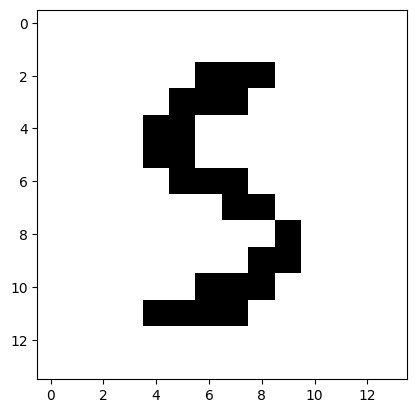

In [5]:
reconst = detokenize_MNIST(output, patch_size=2, account_for_labels=True).cpu()
plt.imshow(reconst[0], cmap='gray_r')

Let's now generate 10 random samples for all 10 classes. Most should look quite reasonable.

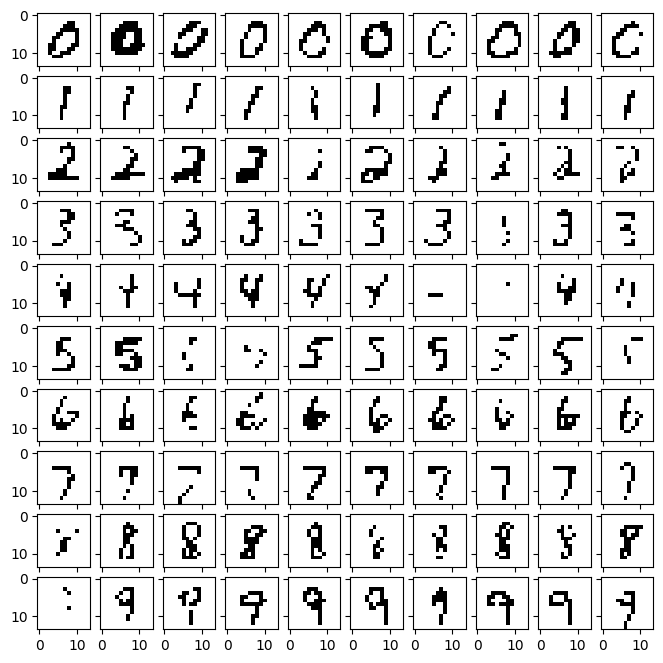

In [6]:
def generate_samples(model, num_steps=8, temp=1.0, top_p=0.0, top_k=0.0, n_samples=10):
    fig = plt.figure(figsize=(8., 8.))
    grid = ImageGrid(fig, 111, nrows_ncols=(10, n_samples), axes_pad=0.1)
    for label in range(10):
        for sample_idx in range(n_samples):
            grid_idx = label * n_samples + sample_idx
            
            seq = torch.zeros(50, dtype=torch.long, device=device)
            mask = torch.ones(50, dtype=torch.bool, device=device)
            seq[0] = label
            mask[0] = False
            output = model.generate(seq, mask, num_steps=num_steps, temp=temp, top_p=top_p, top_k=top_k, return_history=False)
            
            reconst = detokenize_MNIST(output, patch_size=2, account_for_labels=True).cpu()
            grid[grid_idx].imshow(reconst[0], cmap='Greys', vmin=0, vmax=1)
    plt.show()
    
generate_samples(model, num_steps=8, temp=0.7, top_p=0.9, top_k=0.0)

### 2.5 Open-ended questions (10 points each)

Please answer the following questions. You may use additional cells to demonstrate your answers if necessary.

#### 2.5.1 Intermediate generation steps

`model.generate` has an optional flag `return_history`. Show the intermediate generation steps. What do you observe?

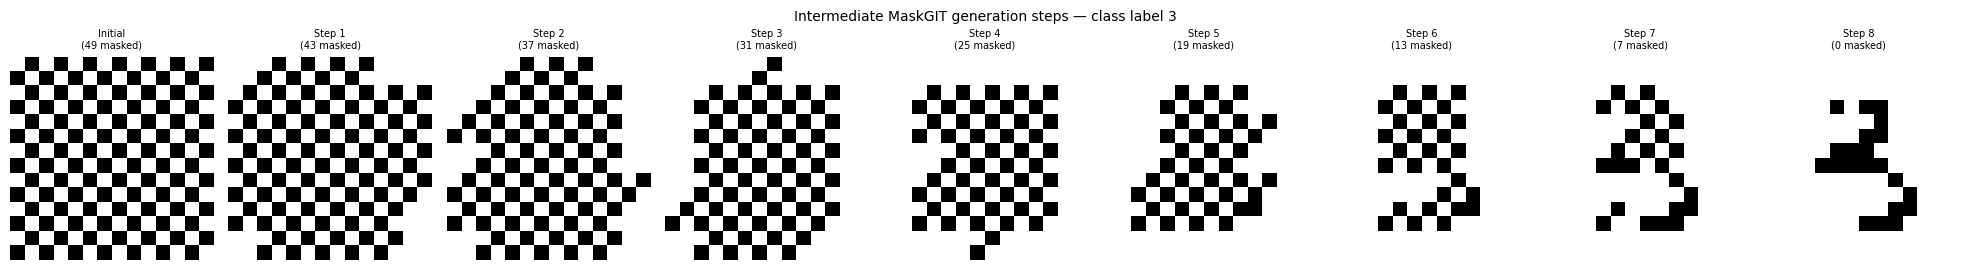

In [7]:
label = 3

seq = torch.zeros(50, dtype=torch.long, device=device)
mask = torch.ones(50, dtype=torch.bool, device=device)
seq[0] = label
mask[0] = False

# return_history=True returns (seq_history, mask_history), both tensors of shape (num_steps+1, L)
# The first row is the initial state (before any unmasking), the remaining rows are after each step.
seq_history, mask_history = model.generate(seq.clone(), mask.clone(), num_steps=8, temp=1.0, top_p=0.9, return_history=True)

n_steps = seq_history.shape[0]  # = num_steps + 1 (includes initial state)
fig, axes = plt.subplots(1, n_steps, figsize=(2.2 * n_steps, 2.8))
for i in range(n_steps):
    step_seq = seq_history[i].unsqueeze(0)  # shape (1, L)
    reconst = detokenize_MNIST(step_seq, patch_size=2, account_for_labels=True).cpu()
    n_masked = mask_history[i].sum().item()
    axes[i].imshow(reconst[0], cmap='Greys', vmin=0, vmax=1)
    title = 'Initial' if i == 0 else f'Step {i}'
    axes[i].set_title(f'{title}\n({int(n_masked)} masked)', fontsize=7)
    axes[i].axis('off')

plt.suptitle(f'Intermediate MaskGIT generation steps — class label {label}', fontsize=10)
plt.tight_layout()
plt.show()





The initial state (step 0) shows the fully masked image. At each step the model simultaneously predicts ALL masked tokens in parallel, and then "unmasks" only the top-k most confident positions (highest max logit).

Early steps fill in the most globally distinctive patches: the background and the broad strokes that strongly identify the digit class appear first. Later steps progressively refine finer details and fill in ambiguous boundary regions.


#### 2.5.2 Number of inference steps

With MaskGIT, we can freely choose the number of inference steps `k`. We default to `k=8`, but how does generation with `k` = 1, 4, 8, 16, 32, 49 perform? What do you observe?

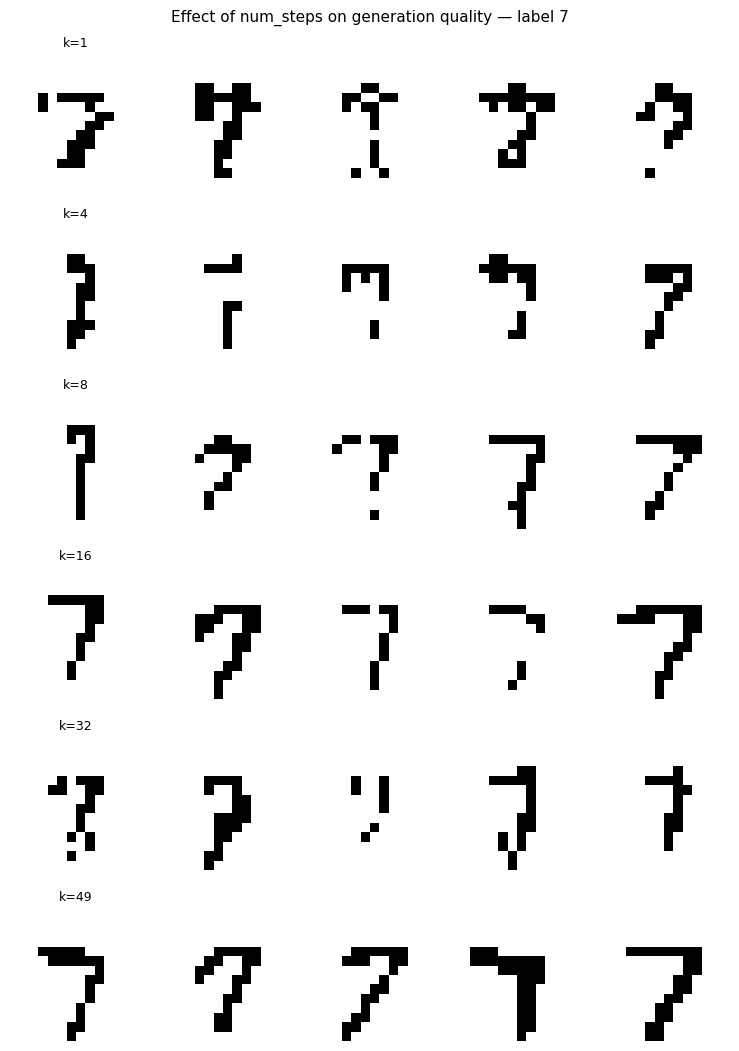

In [8]:
num_steps_list = [1, 4, 8, 16, 32, 49]
n_samples = 5
label = 7  

fig, axes = plt.subplots(len(num_steps_list), n_samples, figsize=(n_samples * 1.5, len(num_steps_list) * 1.8))

for row, num_steps in enumerate(num_steps_list):
    for col in range(n_samples):
        seq = torch.zeros(50, dtype=torch.long, device=device)
        mask = torch.ones(50, dtype=torch.bool, device=device)
        seq[0] = label
        mask[0] = False
        output = model.generate(seq.clone(), mask.clone(), num_steps=num_steps, temp=0.9, top_p=0.9, return_history=False)
        reconst = detokenize_MNIST(output, patch_size=2, account_for_labels=True).cpu()
        axes[row, col].imshow(reconst[0], cmap='Greys', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(f'k={num_steps}', fontsize=9)

plt.suptitle(f'Effect of num_steps on generation quality — label {label}', fontsize=11)
plt.tight_layout()
plt.show()



The quality increase from few to many steps is large at the low end (1 to 16) and
diminishes quickly. k=49 (max) produces the best performance.

---

## 3 Training nanoGPT on TinyStories

Masked generation is quite common for image generation, but has seen a recent resurgence for language models too (e.g. see [LLaDA](https://ml-gsai.github.io/LLaDA-demo/)). 
Let's run a little experiment and train a masked model on TinyStories, just as we did with nanoGPT.

### 3.1 Loading the tokenizer and helper functions

In [9]:
# Load the GPT-2 tokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2", trust_remote_code=True)

# Add padding, start-of-sequence, and end-of-sequence tokens
tokenizer.add_special_tokens({'pad_token': '[PAD]'})
tokenizer.add_special_tokens({
    'bos_token': '[SOS]',
    'eos_token': '[EOS]',
})
tokenizer._tokenizer.post_processor = TemplateProcessing(
    single="[SOS] $A [EOS]",
    special_tokens=[('[EOS]', tokenizer.eos_token_id), ('[SOS]', tokenizer.bos_token_id)],
)
tokenizer

GPT2TokenizerFast(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '[SOS]', 'eos_token': '[EOS]', 'unk_token': '<|endoftext|>', 'pad_token': '[PAD]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	50257: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	50258: AddedToken("[SOS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	50259: AddedToken("[EOS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [10]:
def token_ids_to_text(token_ids, text_tokenizer):
    """ Helper function to turn token sequences back to well-formatted text. """
    decoded = text_tokenizer.decode(token_ids)
    # Remove [SOS], [EOS], and [PAD] tokens along with surrounding horizontal whitespace only.
    decoded = re.sub(r'[ \t]*\[(SOS|EOS|PAD)\][ \t]*', ' ', decoded)
    # Collapse extra horizontal spaces in each line without touching newline characters.
    decoded = '\n'.join([re.sub(r'[ \t]+', ' ', line).strip() for line in decoded.splitlines()])
    return decoded

### 3.2 Training the model

We defined a training config for you in: `cfgs/nanoMaskGIT/tinystories_d8w512.yaml`. Please familiarize yourself with all parts.
Please don't forget to replace the Weights & Bias entity with your own.

On a 2xV100 node, you can start the training like:
```
OMP_NUM_THREADS=1 torchrun --nproc_per_node=2 run_training.py --config cfgs/nanoMaskGIT/tinystories_d8w512.yaml
```

This training should take over one hour. You should reach a final validation loss around 2.05, and your loss curves should look something like the following:

<img src="./assets/nanoMaskGIT_tinystories.png" alt="nanoMaskGIT TinyStories loss curves" width="1000">

### 3.3 Show your loss curves (10 points)

Screenshot your loss curves and show them here. Add the image to the `assets` directory and change the path in the markdown. You will get 10 points for reasonable loss curves (similar to the sample loss curves above).

[Note] Your screenshot must clearly show your Weights & Biases (W&B) account (username/entity), usually visible in the top-right corner of the page.

<img src="./assets/git_story.png" alt="nanoMaskGIT TinyStories loss curves" width="1000">

### 3.4 Evaluating the model (10 points)

After you completed the training, load the model with the following cell. You may need to adjust the path if you changed it.
You will get 10 points if the outputs look reasonable (similar to the sample outputs provided below).

Hint: You can also load intermediate safetensors checkpoints to check the progress during training.

In [11]:
ckpt_path = './outputs/nanoMaskGIT/tinystories_d8w512/checkpoint-final.safetensors'
model = load_model_from_safetensors(ckpt_path, device=device)
print(f'{model.get_num_params() / 10**6}M parameters')

25.174528M parameters


Let's generate some random (unconditional) stories!

In [12]:
for _ in range(5):
    seq = torch.zeros(256, dtype=torch.long, device=device)
    mask = torch.ones(256, dtype=torch.bool, device=device)
    output = model.generate(seq, mask, num_steps=128, temp=1.0, top_k=100, return_history=False)
    print(token_ids_to_text(output[0], text_tokenizer=tokenizer))
    print('\n' + '-'*50 + '\n')

L upon a time, there was a little girl called Lily. One day she wanted to see the moon around her. She looked up her eyes, and to the the moon turn to the moon glow. Lily watched and disappeared light until the moon lit glow again..

--------------------------------------------------



Once upon a time, there was a little girl. She was three but already was only about the sea or explore. world had her already. One

my would told her that if was a to go, but never find scared she. Today

was so excited! She ran never gone go into to the sea.

Their mommy said she should go away an adventurous around the. " they'll to find sure I slipped," she said.

They came to a closer island. It had so much sight to She touched a cliff island and she looked what it felt like she was now on.

Suddenly mommy smiled at

"It's safe, honey," said her little girl. " said we to get here." The sea now was still far." put to her mom, and so did her best.

Once the best and there were new people, so knew that a reliable was to of the sea. They looked so nice, hugged it one the time time to stay a tree.

But soon never had it. the memories girl had to go back home, so thanked hermy and said goodbye and went home.

The little girl never had to have her fun at the sea again,

------------------

Once upon a time, there was a little girl.

--------------------------------------------------



Once there was a curious girl called Jane. Mary liked with her pretty blocks. One day

--------------------------------------------------



Once upon a time, was a clown

--------------------------------------------------



### 3.5 Open-ended questions (10 points each)

Please answer the following questions. You may use additional cells to demonstrate your answers if necessary.

#### 3.5.1 Intermediate generation steps

Similar as in 2.5.1, `model.generate` has an optional flag `return_history`. Show the intermediate generation steps. What do you observe?

In [13]:
seq = torch.zeros(256, dtype=torch.long, device=device)
mask = torch.ones(256, dtype=torch.bool, device=device)

# return_history=True returns (seq_history, mask_history) of shape (num_steps+1, L)
# We use num_steps=16 so we have a manageable number of intermediate frames to display.
seq_history, mask_history = model.generate(
    seq.clone(), mask.clone(), num_steps=16, temp=1.0, top_k=100, return_history=True
)

print("=== Intermediate text generation steps ===\n")
for i in range(seq_history.shape[0]):
    step_seq = seq_history[i]
    n_masked = mask_history[i].sum().item()
    text = token_ids_to_text(step_seq, text_tokenizer=tokenizer)
    step_label = "Initial" if i == 0 else f"Step {i:2d}"
    print(f"[{step_label} | masked: {int(n_masked):3d}]  {text[:120]}")
print()



=== Intermediate text generation steps ===

[Initial | masked: 256]  !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
[Step  1 | masked: 240]  Once had walking time, there was a!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
[Step  2 | masked: 224]  Once had walking time, there was a!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
[Step  3 | masked: 208]  Once had walking time, there was a!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
[Step  4 | masked: 192]  Once had walking time, there was a!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
[Step  5 | masked: 176]  Once had walking time, there was a!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
[Step  6 | masked: 160]  Once had walking time, there was a!!!!!!!!!!!!!!!!!!!!!

**Observations:**

Initially, all 256 tokens are masked and then suddenly 16 tokens are unmasked simultaneously with almost no surrounding context. The model falls back on the most statistically common patterns in TinyStories (e.g. "Once", "there was a"), but without mutual constraint these words can combine incoherently (e.g. "Once had walking time"). From step 11 onward, "was" is unmasked. Later no evident changes any more.
Unlike nanoGPT fills tokens strictly left-to-right and every new token has full causal context, MaskGIT fills tokens in confidence order across the whole sequence, which allows flexible parallel decoding but introduces early consistency errors that cannot be corrected in later steps.


#### 3.5.2 Number of inference steps

Similar as in 2.5.1, with MaskGIT, we can freely choose the number of inference steps `k`. We default to `k=8`, but how does generation with `k` = 1, 4, 8, 16, 32, 49 perform? What do you observe?

In [14]:
num_steps_list = [1, 4, 8, 16, 32, 128]

print("=== Effect of num_steps on TinyStories text generation ===\n")
for num_steps in num_steps_list:
    seq = torch.zeros(256, dtype=torch.long, device=device)
    mask = torch.ones(256, dtype=torch.bool, device=device)
    output = model.generate(seq.clone(), mask.clone(), num_steps=num_steps, temp=1.0, top_k=100, return_history=False)
    text = token_ids_to_text(output[0], text_tokenizer=tokenizer)
    print(f"--- num_steps={num_steps} ---")
    print(text[:400])
    print()


=== Effect of num_steps on TinyStories text generation ===

--- num_steps=1 ---
Once upon was a, there was a little called liked to lived. was many but with.. it things The. HeOne hermy the decided and said. when out They was
The
the He He
to and the for
They the go ran to to the, you and the the to to was's
,,,'s it,, didn and.. the.. the the very she and and. and,The was said the but to Lily!

was, in felt in, out for the want It the
his€ you the and
up so She to was to It.

--- num_steps=4 ---
Once and was time girl there was a little girl her name was called. she She was She three house. her her a garden playing
. a girl go. in

when..

the
like she and of. got
girl
The.'t, a wanted
down girl
found a was to her and bedroom
She up there,'t,! She outside
I and

come I for and
out
you and. mom mom friend, the
friend do.?" but She! it, "I saw is was all the other You!" The be laughed with 

--- num_steps=8 ---
Onceila a time, there was her best girl loved and She She was always happy f

--- num_steps=16 ---
Once upon a time, there on a calendar.



--- num_steps=32 ---
Once upon a time, was was loved to crawl that



--- num_steps=128 ---
Lmy and an obedient girl in the house. She day she'd be the best in the house!



For text generation, more steps improve quality but the gains slow
down. n=1,2,4 produce crappy output while n=128 produces highest quality with fluent text. 

#### 3.5.3 Comparison to autoregressive generation

How would you compare these results to the ones you got from nanoGPT? What are some failure modes you observe? And what could be some benefits? Do you have any thoughs on how we can improve text generation with masked models, or should we just stick to autoregressive models?

nanoGPT generally produces more coherent, natural-sounding text than nanoMaskGIT at the same model size and compute budget. The autoregressive left-to-right conditioning means every token is predicted with full context of all *preceding* tokens, which helps maintain grammatical correctness and narrative consistency over long sequences. nanoMaskGIT often produces text that is locally fluent in short phrases but globally inconsistent — the story may abruptly change topic or character without logical motivation.

Failure modes of nanoMaskGIT on text:
Incorrect grammar and crappy logics when using small steps to generate texts. Using proper steps, the text that is locally fluent in short phrases but globally inconsistent.

Potential benefits of masked generation for text:
Multiple tokens can be decoded simultaneously, which can be significantly faster than token-by-token autoregressive generation.
Also masked models trivially support infilling / text editing while Autoregressive models normally cannot do.

Should we stick to autoregressive models for text?

For pure unconditional text generation quality, autoregressive models are currently superior and easier to scale. Recent work on discrete diffusion language models (e.g., LLaDA) has substantially closed the gap, but a quality deficit remains at equal model size. However, for applications requiring controllable editing, parallel decoding, or bidirectional context, masked models are the right choice.


## 4 Further reading

Here is some further reading material should you want to dive deeper on masked modeling.

Masked image generation:
- [MaskGIT: Masked Generative Image Transformer](https://arxiv.org/abs/2202.04200)
- [Muse: Text-To-Image Generation via Masked Generative Transformers](https://arxiv.org/abs/2301.00704)
- [MAGE: MAsked Generative Encoder to Unify Representation Learning and Image Synthesis](https://arxiv.org/abs/2211.09117)
- [Randomized Autoregressive Visual Generation](https://arxiv.org/abs/2411.00776)
- [RandAR: Decoder-only Autoregressive Visual Generation in Random Orders](https://arxiv.org/abs/2412.01827)
- [Autoregressive Image Generation without Vector Quantization](https://arxiv.org/abs/2406.11838)
- [4M: Massively Multimodal Masked Modeling](https://arxiv.org/abs/2312.06647)

Masked text generation:
- [Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer](https://arxiv.org/abs/1910.10683)
- [Structured Denoising Diffusion Models in Discrete State-Spaces](https://arxiv.org/abs/2107.03006)
- [Large Language Diffusion Models](https://arxiv.org/abs/2502.09992)

Masked pre-training:
- [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](https://arxiv.org/abs/1810.04805)
- [RoBERTa: A Robustly Optimized BERT Pretraining Approach](https://arxiv.org/abs/1907.11692)
- [ELECTRA: Pre-training Text Encoders as Discriminators Rather Than Generators](https://arxiv.org/abs/2003.10555)
- [Masked Autoencoders Are Scalable Vision Learners](https://arxiv.org/abs/2111.06377)
- [BEiT: BERT Pre-Training of Image Transformers](https://arxiv.org/abs/2106.08254)
- [BEiT v2: Masked Image Modeling with Vector-Quantized Visual Tokenizers](https://arxiv.org/abs/2208.06366)